# 06 — DistilBERT Sentiment Classification

In this notebook, we build a Transformer-based sentiment classifier
for the IMDb dataset.

Before training, we first learn how Transformer inputs work:

1. Tokenization
2. Token IDs
3. Special tokens
4. Padding
5. Truncation
6. Attention masks

Then we fine-tune DistilBERT for binary sentiment classification.

Labels:

- 0 = negative
- 1 = positive

In [51]:
%pip install transformers

Looking in indexes: https://pypi.org/simple/
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

In [53]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers


In [54]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

In [55]:
dataset = load_from_disk(
    str(DATA_PATH)
)

train_df = (
    dataset["train"]
    .to_pandas()[["text", "label"]]
    .copy()
)

validation_df = (
    dataset["validation"]
    .to_pandas()[["text", "label"]]
    .copy()
)

print(
    "Train:",
    f"{len(train_df):,}",
)

print(
    "Validation:",
    f"{len(validation_df):,}",
)

Train: 19,823
Validation: 4,956


In [56]:
MODEL_NAME = (
    "distilbert-base-uncased"
)

In [57]:
tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME
    )
)

In [58]:
example_text = (
    "I did not like this movie."
)

print(
    example_text
)

I did not like this movie.


In [59]:
tokens = tokenizer.tokenize(
    example_text
)

tokens

['i', 'did', 'not', 'like', 'this', 'movie', '.']

In [60]:
token_ids = (
    tokenizer
    .convert_tokens_to_ids(
        tokens
    )
)

list(
    zip(
        tokens,
        token_ids,
    )
)

[('i', 1045),
 ('did', 2106),
 ('not', 2025),
 ('like', 2066),
 ('this', 2023),
 ('movie', 3185),
 ('.', 1012)]

In [61]:
encoded_example = tokenizer(
    example_text
)

encoded_example

{'input_ids': [101, 1045, 2106, 2025, 2066, 2023, 3185, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [62]:
tokens_with_special_tokens = (
    tokenizer
    .convert_ids_to_tokens(
        encoded_example[
            "input_ids"
        ]
    )
)

tokens_with_special_tokens

['[CLS]', 'i', 'did', 'not', 'like', 'this', 'movie', '.', '[SEP]']

In [63]:
token_table = pd.DataFrame(
    {
        "token": (
            tokens_with_special_tokens
        ),
        "input_id": (
            encoded_example[
                "input_ids"
            ]
        ),
        "attention_mask": (
            encoded_example[
                "attention_mask"
            ]
        ),
    }
)

token_table

,token,input_id,attention_mask
0,[CLS],101,1
1,i,1045,1
2,did,2106,1
3,not,2025,1
4,like,2066,1
5,this,2023,1
6,movie,3185,1
7,.,1012,1
8,[SEP],102,1


## 2. Padding and attention masks

Transformer batches must have a rectangular shape.

Because texts have different lengths, shorter sequences need padding.

The attention mask tells the model which positions contain real tokens
and which positions are only padding.

In [64]:
batch_texts = [
    "Great movie.",
    "This movie was surprisingly good and very entertaining.",
]

batch_texts

['Great movie.', 'This movie was surprisingly good and very entertaining.']

In [65]:
without_padding = tokenizer(
    batch_texts,
    padding=False,
)

without_padding

{'input_ids': [[101, 2307, 3185, 1012, 102], [101, 2023, 3185, 2001, 10889, 2204, 1998, 2200, 14036, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [66]:
for index, input_ids in enumerate(
    without_padding["input_ids"]
):
    print(
        f"Text {index}:",
        len(input_ids),
        "tokens",
    )

Text 0: 5 tokens
Text 1: 11 tokens


In [67]:
padded_batch = tokenizer(
    batch_texts,
    padding=True,
)

padded_batch

{'input_ids': [[101, 2307, 3185, 1012, 102, 0, 0, 0, 0, 0, 0], [101, 2023, 3185, 2001, 10889, 2204, 1998, 2200, 14036, 1012, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [68]:
for index, input_ids in enumerate(
    padded_batch["input_ids"]
):
    print(
        f"Text {index}:",
        len(input_ids),
        "tokens",
    )

Text 0: 11 tokens
Text 1: 11 tokens


In [69]:
for index, input_ids in enumerate(
    padded_batch["input_ids"]
):
    tokens = tokenizer.convert_ids_to_tokens(
        input_ids
    )

    print(
        f"Text {index}:"
    )

    print(tokens)

    print()

Text 0:
['[CLS]', 'great', 'movie', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Text 1:
['[CLS]', 'this', 'movie', 'was', 'surprisingly', 'good', 'and', 'very', 'entertaining', '.', '[SEP]']



In [70]:
for index in range(
    len(batch_texts)
):
    tokens = (
        tokenizer
        .convert_ids_to_tokens(
            padded_batch[
                "input_ids"
            ][index]
        )
    )

    attention_mask = (
        padded_batch[
            "attention_mask"
        ][index]
    )

    display_df = pd.DataFrame(
        {
            "token": tokens,
            "attention_mask": attention_mask,
        }
    )

    print(
        f"Text {index}:"
    )

    display(display_df)

Text 0:


,token,attention_mask
0,[CLS],1
1,great,1
2,movie,1
3,.,1
4,[SEP],1
5,[PAD],0
6,[PAD],0
7,[PAD],0
8,[PAD],0
9,[PAD],0


Text 1:


,token,attention_mask
0,[CLS],1
1,this,1
2,movie,1
3,was,1
4,surprisingly,1
5,good,1
6,and,1
7,very,1
8,entertaining,1
9,.,1


In [71]:
tensor_batch = tokenizer(
    batch_texts,
    padding=True,
    return_tensors="pt",
)

tensor_batch

{'input_ids': tensor([[  101,  2307,  3185,  1012,   102,     0,     0,     0,     0,     0,
             0],
        [  101,  2023,  3185,  2001, 10889,  2204,  1998,  2200, 14036,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [72]:
print(
    type(
        tensor_batch[
            "input_ids"
        ]
    )
)

print(
    type(
        tensor_batch[
            "attention_mask"
        ]
    )
)

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [73]:
long_text = (
    "This movie was very interesting. "
    * 200
)

print(
    "Characters:",
    len(long_text),
)

Characters: 6600


In [74]:
long_tokens = tokenizer.tokenize(
    long_text
)

print(
    "Number of tokens:",
    len(long_tokens),
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1200 > 512). Running this sequence through the model will result in indexing errors


Number of tokens: 1200


In [75]:
truncated_example = tokenizer(
    long_text,
    truncation=True,
    max_length=16,
)

print(
    "Number of input IDs:",
    len(
        truncated_example[
            "input_ids"
        ]
    ),
)

Number of input IDs: 16


In [76]:
truncated_tokens = (
    tokenizer
    .convert_ids_to_tokens(
        truncated_example[
            "input_ids"
        ]
    )
)

truncated_tokens

['[CLS]',
 'this',
 'movie',
 'was',
 'very',
 'interesting',
 '.',
 'this',
 'movie',
 'was',
 'very',
 'interesting',
 '.',
 'this',
 'movie',
 '[SEP]']

In [77]:
encoded_batch = tokenizer(
    batch_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)

encoded_batch

{'input_ids': tensor([[  101,  2307,  3185,  1012,   102,     0,     0,     0,     0,     0,
             0],
        [  101,  2023,  3185,  2001, 10889,  2204,  1998,  2200, 14036,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [78]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device,
)

Device: cuda


## 3. Load the pretrained DistilBERT classifier

We load pretrained DistilBERT weights and attach a classification
head for our two IMDb sentiment classes.

Classes:

- 0 = negative
- 1 = positive

In [79]:
id2label = {
    0: "neg",
    1: "pos",
}

label2id = {
    "neg": 0,
    "pos": 1,
}

model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=id2label,
        label2id=label2id,
    )
)

model = model.to(
    device
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [80]:
print(
    "Number of labels:",
    model.config.num_labels,
)

print(
    "ID to label:",
    model.config.id2label,
)

print(
    "Label to ID:",
    model.config.label2id,
)

Number of labels: 2
ID to label: {0: 'neg', 1: 'pos'}
Label to ID: {'neg': 0, 'pos': 1}


In [81]:
example_batch = tokenizer(
    batch_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)

example_batch

{'input_ids': tensor([[  101,  2307,  3185,  1012,   102,     0,     0,     0,     0,     0,
             0],
        [  101,  2023,  3185,  2001, 10889,  2204,  1998,  2200, 14036,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [82]:
example_batch = {
    key: value.to(device)
    for key, value
    in example_batch.items()
}

In [83]:
model.eval()

with torch.inference_mode():
    outputs = model(
        **example_batch
    )

In [84]:
logits = outputs.logits

print(
    "Logits:"
)

print(
    logits
)

print(
    "Shape:",
    logits.shape,
)

Logits:
tensor([[0.0453, 0.0272],
        [0.0584, 0.0300]], device='cuda:0')
Shape: torch.Size([2, 2])


In [85]:
probabilities = torch.softmax(
    logits,
    dim=-1,
)

probabilities

tensor([[0.5045, 0.4955],
        [0.5071, 0.4929]], device='cuda:0')

In [86]:
probability_sums = (
    probabilities
    .sum(
        dim=1
    )
)

probability_sums

tensor([1., 1.], device='cuda:0')

In [87]:
predicted_class_ids = (
    probabilities
    .argmax(
        dim=1
    )
)

predicted_class_ids

tensor([0, 0], device='cuda:0')

In [88]:
predicted_labels = [
    model.config.id2label[
        class_id.item()
    ]
    for class_id
    in predicted_class_ids
]

predicted_labels

['neg', 'neg']

In [89]:
prediction_demo_df = pd.DataFrame(
    {
        "text": batch_texts,
        "negative_probability": (
            probabilities[
                :, 0
            ]
            .cpu()
            .numpy()
        ),
        "positive_probability": (
            probabilities[
                :, 1
            ]
            .cpu()
            .numpy()
        ),
        "prediction": (
            predicted_labels
        ),
    }
)

prediction_demo_df

,text,negative_probability,positive_probability,prediction
0,Great movie.,0.504535,0.495465,neg
1,This movie was surprisingly good and very ente...,0.507092,0.492908,neg


In [90]:
from torch.utils.data import (
    DataLoader,
    Dataset,
)

## 4. Build the Transformer training pipeline

We now create a PyTorch Dataset and DataLoader for IMDb reviews.

Each batch will contain:

- `input_ids`
- `attention_mask`
- `labels`

Texts are dynamically padded inside each batch.

In [91]:
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 8

In [92]:
class IMDbTransformerDataset(
    Dataset
):
    def __init__(
        self,
        texts,
        labels,
    ):
        self.texts = list(
            texts
        )

        self.labels = np.asarray(
            labels,
            dtype=np.int64,
        )

    def __len__(
        self,
    ):
        return len(
            self.labels
        )

    def __getitem__(
        self,
        index,
    ):
        return {
            "text": (
                self.texts[
                    index
                ]
            ),
            "label": int(
                self.labels[
                    index
                ]
            ),
        }

In [93]:
train_dataset = (
    IMDbTransformerDataset(
        texts=train_df[
            "text"
        ],
        labels=train_df[
            "label"
        ],
    )
)

validation_dataset = (
    IMDbTransformerDataset(
        texts=validation_df[
            "text"
        ],
        labels=validation_df[
            "label"
        ],
    )
)

In [94]:
print(
    "Train dataset:",
    len(train_dataset),
)

print(
    "Validation dataset:",
    len(validation_dataset),
)

Train dataset: 19823
Validation dataset: 4956


In [95]:
train_dataset[0]

{'text': 'This cool Marvel superhero game pays proper tribute by staying true to the comics. Of all the Marvel superhero games that have been so lame with weak graphics and gameplay, Spiderman improves in both departments. It also features the voice of Stan Lee, the creator of Spiderman comics.<br /><br />As you\'d expect Spiderman does whatever a spider can. He does more than spin webs. In fact, he uses them as weapons and shields. When he\'s not using web in combat, he punches and kicks as well. Spidey has his hands full as he battles Venom, Rhino, Mysterio, Scorpion, and Dr. Octopus to name a few. Look for Captain America in a cameo.<br /><br />Most of the levels are challenging, but some of them require patience to beat. The only complaint about this game is that it\'s so short and can be completed in less than three hours. If you\'re a real Marvel superhero fan, this game is for you but don\'t expect long gameplay. Better luck in "Spiderman 2." My evaluation: 9 out of 10.',
 'labe

In [96]:
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 16
VALIDATION_BATCH_SIZE = 32

In [97]:
def collate_transformer_batch(
    batch,
):
    texts = [
        item["text"]
        for item in batch
    ]

    labels = [
        item["label"]
        for item in batch
    ]

    encoded_batch = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    encoded_batch[
        "labels"
    ] = torch.tensor(
        labels,
        dtype=torch.long,
    )

    return encoded_batch

In [98]:
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=(
        collate_transformer_batch
    ),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=(
        VALIDATION_BATCH_SIZE
    ),
    shuffle=False,
    collate_fn=(
        collate_transformer_batch
    ),
)

In [99]:
example_training_batch = next(
    iter(
        train_loader
    )
)

In [100]:
for key, value in (
    example_training_batch.items()
):
    print(
        key,
        value.shape,
        value.dtype,
    )

input_ids torch.Size([16, 128]) torch.int64
token_type_ids torch.Size([16, 128]) torch.int64
attention_mask torch.Size([16, 128]) torch.int64
labels torch.Size([16]) torch.int64


In [101]:
first_input_ids = (
    example_training_batch[
        "input_ids"
    ][0]
)

decoded_text = tokenizer.decode(
    first_input_ids,
    skip_special_tokens=False,
)

print(
    decoded_text
)

[CLS] you can often tell a movie didn ' t turn out like it should by the heavy use of a narrator. this film features this device throughout. richard jobson not entirely content to write direct and even fund some of this film adds to his credits by reading excerpts of his own semi - autobiographical writing which combined with some pretty editing manages to gloss over what is a dull depressing tale which he must be mistaking for genuine art - house. kevin mckidd puts in a good performance. everyone else is okay. < br / > < br / > budget constraints meant that all scenes are shot in daylight though most are obviously meant [SEP]


In [102]:
print(
    tokenizer.decode(
        first_input_ids,
        skip_special_tokens=True,
    )
)

you can often tell a movie didn ' t turn out like it should by the heavy use of a narrator. this film features this device throughout. richard jobson not entirely content to write direct and even fund some of this film adds to his credits by reading excerpts of his own semi - autobiographical writing which combined with some pretty editing manages to gloss over what is a dull depressing tale which he must be mistaking for genuine art - house. kevin mckidd puts in a good performance. everyone else is okay. < br / > < br / > budget constraints meant that all scenes are shot in daylight though most are obviously meant


In [103]:
first_attention_mask = (
    example_training_batch[
        "attention_mask"
    ][0]
)

print(
    "Sequence length:",
    len(
        first_attention_mask
    ),
)

print(
    "Real tokens:",
    int(
        first_attention_mask.sum()
    ),
)

Sequence length: 128
Real tokens: 128


In [104]:
example_training_batch[
    "labels"
]

tensor([0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0])

In [105]:
batch_on_device = {
    key: value.to(
        device
    )
    for key, value
    in example_training_batch.items()
}

In [106]:
model.train()

outputs = model(
    **batch_on_device
)

In [107]:
print(
    "Loss:",
    outputs.loss.item(),
)

print(
    "Logits shape:",
    outputs.logits.shape,
)

Loss: 0.7067948579788208
Logits shape: torch.Size([16, 2])


In [108]:
LEARNING_RATE = 2e-5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [109]:
training_batch = next(
    iter(train_loader)
)

In [110]:
training_batch = {
    key: value.to(device)
    for key, value
    in training_batch.items()
}

In [111]:
parameter_name, parameter = next(
    model.named_parameters()
)

weight_before_training = (
    parameter
    .detach()
    .clone()
)

print(
    "Parameter:",
    parameter_name,
)

print(
    "Shape:",
    parameter.shape,
)

Parameter: distilbert.embeddings.word_embeddings.weight
Shape: torch.Size([30522, 768])


In [112]:
model.train()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [113]:
optimizer.zero_grad()

In [114]:
outputs = model(
    **training_batch
)

In [115]:
loss = outputs.loss

print(
    "Loss before update:",
    loss.item(),
)

print(
    "Logits shape:",
    outputs.logits.shape,
)

Loss before update: 0.7035684585571289
Logits shape: torch.Size([16, 2])


In [116]:
loss.backward()

In [117]:
GRADIENT_CLIP_NORM = 1.0

gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=GRADIENT_CLIP_NORM,
)

print(
    "Gradient norm:",
    gradient_norm.item(),
)

Gradient norm: 1.1495494842529297


In [118]:
optimizer.step()

In [119]:
weight_after_training = (
    parameter
    .detach()
    .clone()
)

In [120]:
weights_changed = (
    not torch.equal(
        weight_before_training,
        weight_after_training,
    )
)

print(
    "Weights changed:",
    weights_changed,
)

Weights changed: True


In [121]:
maximum_weight_change = (
    weight_after_training
    - weight_before_training
).abs().max()

print(
    "Maximum weight change:",
    maximum_weight_change.item(),
)

Maximum weight change: 2.014636993408203e-05


In [122]:
model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=id2label,
        label2id=label2id,
    )
    .to(device)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [123]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [125]:
@torch.no_grad()
def evaluate_transformer(
    model,
    data_loader,
    device,
):
    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    for batch in data_loader:

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        outputs = model(
            **batch
        )

        loss = outputs.loss
        logits = outputs.logits

        batch_size = (
            batch["labels"]
            .size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        predictions = (
            logits
            .argmax(dim=1)
        )

        all_predictions.append(
            predictions.cpu()
        )

        all_labels.append(
            batch["labels"]
            .cpu()
        )

    predictions = (
        torch.cat(
            all_predictions
        )
        .numpy()
    )

    labels = (
        torch.cat(
            all_labels
        )
        .numpy()
    )

    average_loss = (
        total_loss
        / len(
            data_loader.dataset
        )
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
    }

In [126]:
initial_validation_results = (
    evaluate_transformer(
        model=model,
        data_loader=validation_loader,
        device=device,
    )
)

initial_validation_results

{'loss': 0.6906684354200201,
 'accuracy': 0.5583131557707829,
 'precision': 0.5572082379862701,
 'recall': 0.5869827239855364,
 'f1': 0.5717080806104481}

## 5. Fine-tune DistilBERT

We now fine-tune the pretrained DistilBERT model on the IMDb
training split.

After every epoch, we evaluate the model on the validation split.

The model with the highest validation F1 is saved as the best
Transformer checkpoint.

In [127]:
NUMBER_OF_EPOCHS = 2

In [128]:
TRANSFORMER_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "distilbert_imdb"
)

TRANSFORMER_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [129]:
training_history = []

best_validation_f1 = -1.0
best_epoch = None

In [130]:
import time

In [131]:
training_start = (
    time.perf_counter()
)

for epoch in range(
    1,
    NUMBER_OF_EPOCHS + 1,
):

    print(
        f"\nEpoch {epoch}/{NUMBER_OF_EPOCHS}"
    )

    model.train()

    total_training_loss = 0.0

    epoch_start = (
        time.perf_counter()
    )

    for batch_number, batch in enumerate(
        train_loader,
        start=1,
    ):

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(
            **batch
        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        batch_size = (
            batch["labels"]
            .size(0)
        )

        total_training_loss += (
            loss.item()
            * batch_size
        )

        if batch_number % 200 == 0:
            print(
                f"Batch {batch_number:,} | "
                f"Loss: {loss.item():.4f}"
            )

    average_training_loss = (
        total_training_loss
        / len(train_loader.dataset)
    )

    validation_results = (
        evaluate_transformer(
            model=model,
            data_loader=validation_loader,
            device=device,
        )
    )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": (
            average_training_loss
        ),
        "validation_loss": (
            validation_results[
                "loss"
            ]
        ),
        "validation_accuracy": (
            validation_results[
                "accuracy"
            ]
        ),
        "validation_precision": (
            validation_results[
                "precision"
            ]
        ),
        "validation_recall": (
            validation_results[
                "recall"
            ]
        ),
        "validation_f1": (
            validation_results[
                "f1"
            ]
        ),
        "seconds": (
            epoch_seconds
        ),
    }

    training_history.append(
        epoch_record
    )

    print(
        f"Train Loss: "
        f"{average_training_loss:.4f}"
    )

    print(
        f"Validation Loss: "
        f"{validation_results['loss']:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{validation_results['accuracy']:.4f}"
    )

    print(
        f"Validation F1: "
        f"{validation_results['f1']:.4f}"
    )

    print(
        f"Epoch Time: "
        f"{epoch_seconds:.1f}s"
    )

    if (
        validation_results["f1"]
        > best_validation_f1
    ):
        best_validation_f1 = (
            validation_results[
                "f1"
            ]
        )

        best_epoch = epoch

        model.save_pretrained(
            TRANSFORMER_MODEL_DIR
        )

        tokenizer.save_pretrained(
            TRANSFORMER_MODEL_DIR
        )

        print(
            "New best model saved."
        )


Epoch 1/2
Batch 200 | Loss: 0.4457
Batch 400 | Loss: 0.4857
Batch 600 | Loss: 0.2263
Batch 800 | Loss: 0.2353
Batch 1,000 | Loss: 0.2725
Batch 1,200 | Loss: 0.3602
Train Loss: 0.3666
Validation Loss: 0.3117
Validation Accuracy: 0.8684
Validation F1: 0.8710
Epoch Time: 120.2s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best model saved.

Epoch 2/2
Batch 200 | Loss: 0.0903
Batch 400 | Loss: 0.3087
Batch 600 | Loss: 0.3266
Batch 800 | Loss: 0.5276
Batch 1,000 | Loss: 0.5817
Batch 1,200 | Loss: 0.2664
Train Loss: 0.2417
Validation Loss: 0.3063
Validation Accuracy: 0.8745
Validation F1: 0.8737
Epoch Time: 121.0s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best model saved.


In [132]:
total_training_seconds = (
    time.perf_counter()
    - training_start
)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation F1:",
    f"{best_validation_f1:.4f}",
)

print(
    "Total training time:",
    f"{total_training_seconds:.1f}s",
)

Best epoch: 2
Best validation F1: 0.8737
Total training time: 241.7s


In [133]:
training_history_df = (
    pd.DataFrame(
        training_history
    )
)

training_history_df

,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,seconds
0,1,0.366610,0.311669,0.868442,0.858090,0.884291,0.870993,120.237030
1,2,0.241697,0.306311,0.874496,0.883368,0.864202,0.873680,121.048257


## 6. Load the best saved DistilBERT model

Training may finish on an epoch that is not the best epoch.

We therefore reload the checkpoint that achieved the highest
validation F1 before performing final evaluation.

In [134]:
best_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        TRANSFORMER_MODEL_DIR
    )
    .to(device)
)

best_tokenizer = (
    AutoTokenizer
    .from_pretrained(
        TRANSFORMER_MODEL_DIR
    )
)

best_model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [135]:
print(
    "Labels:",
    best_model.config.id2label,
)

print(
    "Number of labels:",
    best_model.config.num_labels,
)

Labels: {0: 'neg', 1: 'pos'}
Number of labels: 2


In [136]:
best_validation_results = (
    evaluate_transformer(
        model=best_model,
        data_loader=validation_loader,
        device=device,
    )
)

best_validation_results

{'loss': 0.3063108279904211,
 'accuracy': 0.8744955609362389,
 'precision': 0.8833675564681724,
 'recall': 0.864202490960225,
 'f1': 0.8736799350121852}

In [137]:
print(
    "Recorded best F1:",
    best_validation_f1,
)

print(
    "Reloaded model F1:",
    best_validation_results[
        "f1"
    ],
)

Recorded best F1: 0.8736799350121852
Reloaded model F1: 0.8736799350121852


In [138]:
test_df = (
    dataset["test"]
    .to_pandas()[["text", "label"]]
    .copy()
)

print(
    "Test examples:",
    f"{len(test_df):,}",
)

Test examples: 25,000


In [139]:
IMDbTransformerDataset

__main__.IMDbTransformerDataset

In [140]:
test_dataset = (
    IMDbTransformerDataset(
        texts=test_df[
            "text"
        ],
        labels=test_df[
            "label"
        ],
    )
)

print(
    "Test dataset:",
    len(test_dataset),
)

Test dataset: 25000


In [141]:
TEST_BATCH_SIZE = 32

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    collate_fn=(
        collate_transformer_batch
    ),
)

In [142]:
def collate_test_batch(
    batch,
):
    texts = [
        item["text"]
        for item in batch
    ]

    labels = [
        item["label"]
        for item in batch
    ]

    encoded_batch = (
        best_tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
    )

    encoded_batch[
        "labels"
    ] = torch.tensor(
        labels,
        dtype=torch.long,
    )

    return encoded_batch

In [143]:
test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_test_batch,
)

In [144]:
@torch.no_grad()
def evaluate_with_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_probabilities = []
    all_labels = []

    for batch in data_loader:

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        outputs = model(
            **batch
        )

        logits = outputs.logits
        loss = outputs.loss

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        batch_size = (
            batch["labels"]
            .size(0)
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        all_predictions.append(
            predictions.cpu()
        )

        all_probabilities.append(
            probabilities.cpu()
        )

        all_labels.append(
            batch["labels"]
            .cpu()
        )

    predictions = (
        torch.cat(
            all_predictions
        )
        .numpy()
    )

    probabilities = (
        torch.cat(
            all_probabilities
        )
        .numpy()
    )

    labels = (
        torch.cat(
            all_labels
        )
        .numpy()
    )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    return {
        "loss": average_loss,
        "predictions": predictions,
        "probabilities": probabilities,
        "labels": labels,
    }

In [145]:
test_start = (
    time.perf_counter()
)

distilbert_test_output = (
    evaluate_with_predictions(
        model=best_model,
        data_loader=test_loader,
        device=device,
    )
)

test_seconds = (
    time.perf_counter()
    - test_start
)

In [146]:
y_test = (
    distilbert_test_output[
        "labels"
    ]
)

test_predictions = (
    distilbert_test_output[
        "predictions"
    ]
)

test_probabilities = (
    distilbert_test_output[
        "probabilities"
    ]
)

In [147]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [148]:
distilbert_accuracy = (
    accuracy_score(
        y_test,
        test_predictions,
    )
)

distilbert_precision = (
    precision_score(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

distilbert_recall = (
    recall_score(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

distilbert_f1 = (
    f1_score(
        y_test,
        test_predictions,
        zero_division=0,
    )
)

In [149]:
print(
    f"Test Loss:      "
    f"{distilbert_test_output['loss']:.4f}"
)

print(
    f"Test Accuracy:  "
    f"{distilbert_accuracy:.4f}"
)

print(
    f"Test Precision: "
    f"{distilbert_precision:.4f}"
)

print(
    f"Test Recall:    "
    f"{distilbert_recall:.4f}"
)

print(
    f"Test F1:        "
    f"{distilbert_f1:.4f}"
)

print(
    f"Test Time:      "
    f"{test_seconds:.1f}s"
)

Test Loss:      0.3114
Test Accuracy:  0.8736
Test Precision: 0.8808
Test Recall:    0.8640
Test F1:        0.8723
Test Time:      39.1s


In [150]:
distilbert_report = (
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "neg",
            "pos",
        ],
        output_dict=True,
        zero_division=0,
    )
)

distilbert_report_df = (
    pd.DataFrame(
        distilbert_report
    )
    .transpose()
)

distilbert_report_df

,precision,recall,f1-score,support
neg,0.866552,0.88312,0.874757,12500.00000
pos,0.880842,0.86400,0.872340,12500.00000
accuracy,0.873560,0.87356,0.873560,0.87356
macro avg,0.873697,0.87356,0.873548,25000.00000
weighted avg,0.873697,0.87356,0.873548,25000.00000


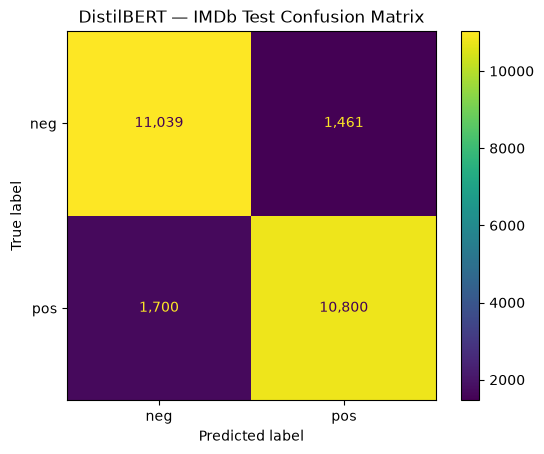

In [151]:
import matplotlib.pyplot as plt
distilbert_confusion_matrix = (
    confusion_matrix(
        y_test,
        test_predictions,
        labels=[0, 1],
    )
)

display = (
    ConfusionMatrixDisplay(
        confusion_matrix=(
            distilbert_confusion_matrix
        ),
        display_labels=[
            "neg",
            "pos",
        ],
    )
)

display.plot(
    values_format=",d"
)

plt.title(
    "DistilBERT — IMDb Test Confusion Matrix"
)

plt.show()

In [152]:
DISTILBERT_REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "distilbert"
    / "test_evaluation"
)

DISTILBERT_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [153]:
distilbert_metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision_positive",
            "recall_positive",
            "f1_positive",
            "test_loss",
            "test_seconds",
            "test_rows",
        ],
        "value": [
            distilbert_accuracy,
            distilbert_precision,
            distilbert_recall,
            distilbert_f1,
            distilbert_test_output[
                "loss"
            ],
            test_seconds,
            len(y_test),
        ],
    }
)

distilbert_metrics_df.to_csv(
    DISTILBERT_REPORT_DIR
    / "test_metrics.csv",
    index=False,
)

distilbert_metrics_df

,metric,value
0,accuracy,0.873560
1,precision_positive,0.880842
2,recall_positive,0.864000
3,f1_positive,0.872340
4,test_loss,0.311351
5,test_seconds,39.129423
6,test_rows,25000.000000
